# Receipt OCR Pipeline (SROIE) — Merchant, Date & Total Extraction

**Name:** Blessing Obasi-Uzoma  
**Project:** Computer Vision Project 1 (Receipt OCR & Information Extraction)  
**Tools:** OpenCV, EasyOCR, Python (Google Colab)  
**Dataset:** SROIE Dataset (Kaggle)  
**Output:** `receipt_predictions.csv` (structured fields per receipt)

---

## Introduction
This project is my first computer vision project and focuses on building an end-to-end Optical Character Recognition (OCR) pipeline that converts scanned receipt images into structured data. The goal is to automatically extract key information from receipts—such as **merchant name**, **transaction date**, and **total amount**—and store the results in a structured format that can be used for record keeping and analysis.

Receipts are real-world “noisy” documents: they may be skewed, faded, blurred, or captured under poor lighting. To handle this, the pipeline applies image preprocessing (grayscale conversion, contrast enhancement, and adaptive thresholding) before running OCR. After text extraction, the detected text is grouped into readable lines and parsed using keyword rules and regular expressions to identify important fields.

This work demonstrates how computer vision can support business processes such as automated expense tracking, accounting workflows, and document digitization by reducing manual data entry.

---

## Project Objectives
- Download and load receipt images from the SROIE dataset  
- Preprocess images to improve text visibility for OCR  
- Perform OCR to detect and recognize receipt text  
- Extract structured fields: **Merchant**, **Date**, and **Total**  
- Run the pipeline on multiple receipts and export results to CSV  

---

## Text Recognition using OCR (Optical Character Recognition)


In [ ]:
pip install pytesseract easyocr

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import pytesseract
import openpyxl
import os
import glob
import easyocr
import re
import random

# Download dataset
path = kagglehub.dataset_download("urbikn/sroie-datasetv2")

print("Path to dataset files:", path)

for root, dirs, files in os.walk(path):
  print(root)
  print(len(files), "files")
  break

Using Colab cache for faster access to the 'sroie-datasetv2' dataset.
Path to dataset files: /kaggle/input/sroie-datasetv2
/kaggle/input/sroie-datasetv2
0 files


Total images: 973


(np.float64(-0.5), np.float64(618.5), np.float64(1406.5), np.float64(-0.5))

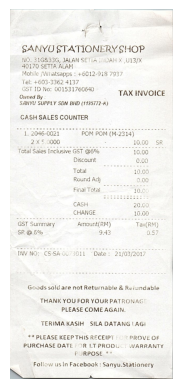

In [ ]:
# load images
images = glob.glob(path + "/**/*.jpg", recursive=True)
print("Total images:", len(images))
img_path = random.choice(images)
img = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

## Convert to Grayscale

- Removes unnecessary color
- Emphasizes text contrast
- Simplifies the data from 3 channels to 1 channels

(np.float64(-0.5), np.float64(618.5), np.float64(1406.5), np.float64(-0.5))

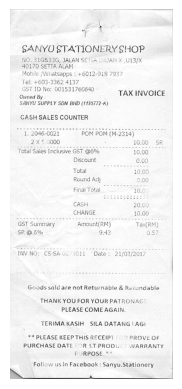

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap="gray")
plt.axis("off")

## Applying Thresholding  

-Making the text to stand out

(np.float64(-0.5), np.float64(618.5), np.float64(1406.5), np.float64(-0.5))

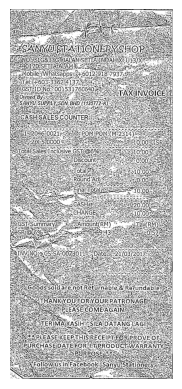

In [ ]:
thresh = cv2.adaptiveThreshold(gray,
                       255,
                       cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                       cv2.THRESH_BINARY,
                       11, 2
                       )
plt.imshow(thresh, cmap="gray")
plt.axis("off")

Run OCR (EasyOCR)

In [ ]:
reader = easyocr.Reader(['en'])

results = reader.readtext(thresh)
for r in results:
  print(r[1])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


NNOST
WONERYSIAOP
NQ
G833
AUAN SBITAENLAH
13X
40170 SETIAAIAM
Mobile /Whatsapps #+601291
9374
Te
7603,3362413
GST;
DiNo 00j531760640
TAXINVOICE
OvnedBy
SANYU SURPRYASDNA BHD (1135712K)
CASHSALESCOUNTER
046-002
POMPOM
M2314)
Xs;0000
sales Incliisive GST@6%
Discount
Tota
Round Adj
Inal
CASH
CHANGE
GSTSumma
Amotint(rM
RM
SRi@ 6%
"3
NVNOACSS4;007301
{e
21/0312017
5Q
dare notReturoable & Refundabl
THANKYQUEORYOURIPATROWAG
PLEASECOMEAGAIN
TERIMAKASIH
SILA DATANG TG)
PLEASEKEEPTHISRECEIPAECREROVEDF 
RORCHASEDATERDRIITPRODUE
WARRANT
#RROSE
Follonjus inFacebook
Sanyu Statione
8 79


Make the OCR readable

In [ ]:
def draw_easyocr_boxes(image_bgr, results):
  img = image_bgr.copy()
  for (box, text, conf) in results:
    pts = np.array(box, dtype=np.int32)
    cv2.polylines(img, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
    x, y = pts[0]
    cv2.putText(img, f"{text} ({conf:2f})", (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)
    return img

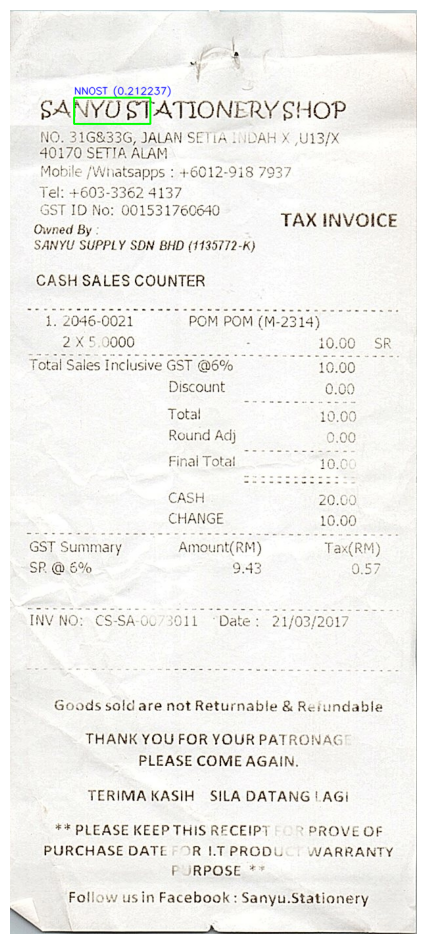

In [ ]:
boxed = draw_easyocr_boxes(img, results)
plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


sort detected text into reading order

In [ ]:
def y_center(box):
  ys = [p[1] for p in box]
  return sum(ys)/len(ys)

def x_center(box):
  xs = [p[0] for p in box]
  return sum(xs)/len(xs)

# sort by y then x
sorted_results = sorted(results, key=lambda r: (y_center(r[0]), x_center(r[0])))

for box, text, conf in sorted_results:
  if conf > 0.25:
     print(text)


WONERYSIAOP
NQ
G833
13X
40170 SETIAAIAM
8 79
9374
Te
GST;
TAXINVOICE
OvnedBy
CASHSALESCOUNTER
046-002
POMPOM
M2314)
Xs;0000
sales Incliisive GST@6%
Discount
Tota
Round Adj
Inal
CASH
CHANGE
GSTSumma
Amotint(rM
RM
"3
21/0312017
NVNOACSS4;007301
{e
THANKYQUEORYOURIPATROWAG
PLEASECOMEAGAIN
TERIMAKASIH
WARRANT
#RROSE
Follonjus inFacebook
Sanyu Statione


Extract Date and Total using rules

In [ ]:
full_text = "\n".join([t for _, t, _ in sorted_results])

# date patterns
date_march = re.search(r'(\d{2}[\/\-]\d{2}[\/\-]\d{4})', full_text)

# total patterns
total_march = re.search(r'(?:Total|TOTAL)\s*(?:RM)?\s*([0-9]+(?:\.[0-9]{2})?)', full_text, re.IGNORECASE)

print("Extracted Date:", date_march.group(1) if date_march else None)
print("Extracted Total:", total_march.group(1) if total_march else None)

Extracted Date: None
Extracted Total: None


In [ ]:
# displays images nicely

def show(img, title="image", size=8):
    plt.figure(figsize=(size, size))

    # If grayscale
    if len(img.shape) == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    plt.title(title)
    plt.axis("off")
    plt.show()

Data Preprocessing


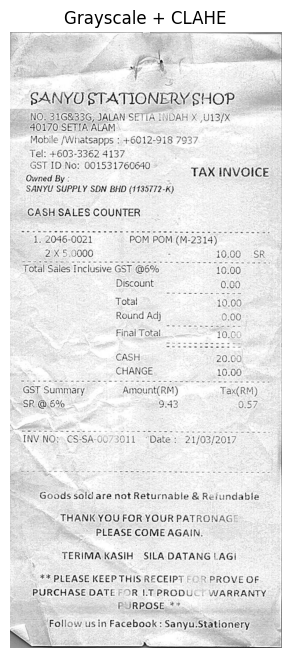

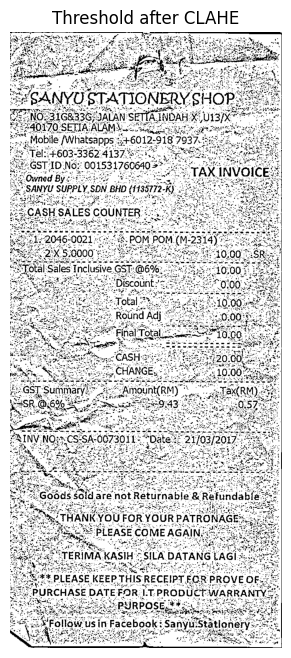

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# increase contrast
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
gray2 = clahe.apply(gray)

thresh2 = cv2.adaptiveThreshold(
    gray2, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    31,  # bigger window helps receipts
    10
)

show(gray2, "Grayscale + CLAHE")
show(thresh2, "Threshold after CLAHE")

In [ ]:
results = reader.readtext(thresh2)

(np.float64(-0.5), np.float64(618.5), np.float64(1406.5), np.float64(-0.5))

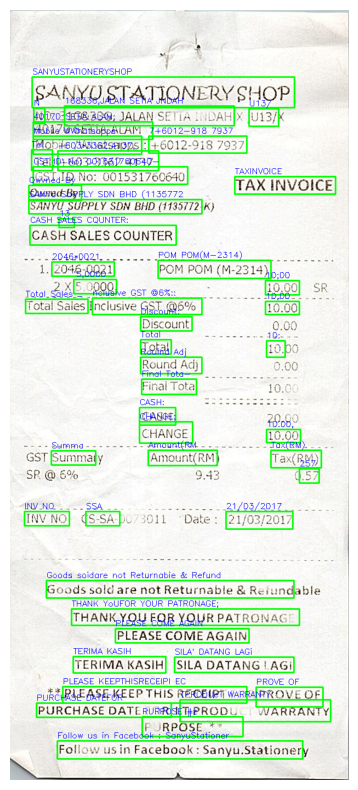

In [ ]:
# visualizing what EasyOCR actually detected

img_copy = img.copy()

for (bbox, text, prob) in results:
    pts = np.array(bbox).astype(int)

    cv2.polylines(img_copy, [pts], True, (0,255,0), 2)

    x, y = pts[0]
    cv2.putText(img_copy, text, (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (255,0,0), 1)

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.axis("off")

Extract TOTAL robustly (works with “Total: number”)

In [ ]:
def y_center(box):
    ys = [p[1] for p in box]
    return sum(ys)/len(ys)

def x_center(box):
    xs = [p[0] for p in box]
    return sum(xs)/len(xs)

def extract_total_from_easyocr(results):
    # Sort in reading order
    sorted_res = sorted(results, key=lambda r: (y_center(r[0]), x_center(r[0])))

    # Keep decent-confidence text and normalize spacing
    texts = []
    for box, text, conf in sorted_res:
        if conf >= 0.25:
            cleaned = text.strip()
            if cleaned:
                texts.append(cleaned)

    full_text = "\n".join(texts)

    # Look for lines containing total keywords
    total_keywords = ["total", "grand total", "amount due", "balance", "payable"]
    lines = full_text.split("\n")

    candidate_lines = [ln for ln in lines if any(k in ln.lower() for k in total_keywords)]

    # Extract numbers from candidates; prefer the last number on the line (often the amount)
    def parse_amount(line):
        # match 42, 42.00, 1,250.50 etc.
        nums = re.findall(r'\b\d{1,3}(?:,\d{3})*(?:\.\d{2})?\b', line)
        if not nums:
            return None
        # take the last number as the likely total
        val = nums[-1].replace(",", "")
        return float(val)

    for ln in reversed(candidate_lines):  # bottom of receipt often contains total
        amt = parse_amount(ln)
        if amt is not None:
            return amt, ln

    # fallback: search the entire text for "total" followed by a number
    m = re.search(r'(?:total|grand total|amount due|balance|payable)\D{0,10}(\d{1,3}(?:,\d{3})*(?:\.\d{2})?)',
                  full_text, re.IGNORECASE)
    if m:
        return float(m.group(1).replace(",", "")), m.group(0)

    return None, None

total_value, total_line = extract_total_from_easyocr(results)
print("TOTAL:", total_value)
print("Matched line:", total_line)

TOTAL: None
Matched line: None


Group OCR results into lines (super important skill)

In [ ]:
def group_into_lines(results, y_tol=12, conf_min=0.25):
    # Keep good results
    items = []
    for box, text, conf in results:
        if conf >= conf_min and text.strip():
            ys = [p[1] for p in box]
            xs = [p[0] for p in box]
            items.append({
                "box": box,
                "text": text.strip(),
                "y": float(np.mean(ys)),
                "x": float(np.mean(xs))
            })
    # Sort by y then x
    items.sort(key=lambda d: (d["y"], d["x"]))

    lines = []
    for it in items:
        placed = False
        for line in lines:
            if abs(it["y"] - line["y"]) <= y_tol:
                line["words"].append(it)

                line["y"] = float(np.mean([w["y"] for w in line["words"]]))
                placed = True
                break
        if not placed:
            lines.append({"y": it["y"], "words": [it]})

    # Sort words in each line left-to-right and join
    joined_lines = []
    for line in lines:
        line["words"].sort(key=lambda w: w["x"])
        joined_lines.append(" ".join([w["text"] for w in line["words"]]))

    return joined_lines

lines = group_into_lines(results, y_tol=12, conf_min=0.25)
print("Sample lines:")
for ln in lines[-15:]:
    print(ln)

Sample lines:
Total
Rouind Adj
Final Tota-
CASH:
CHANGE; 10.00,
Summa Amount(RM Tax(RM)
257
INV NO SSA 21/03/2017
Goods soidare not Returnabie & Refund
THANK YoUFOR YOUR PATRONAGE;
PLEASE COME AGAIN
TERIMA KASIH SILA' DATANG LAGi
PLEASE KEEPTHISRECEIPI EC PROVE OF
PURCHASE DATEFOR TPRODUeT WARRANTY
Follow us in Facebook : SanyuStationer


Extract TOTAL from grouped lines (cleaner match)

In [ ]:
def extract_total_from_lines(lines):
    keywords = ["grand total", "total", "amount due", "balance", "payable"]
    def parse_amount(line):
        nums = re.findall(r'\b\d{1,3}(?:,\d{3})*(?:\.\d{2})?\b', line)
        if not nums:
            return None
        return float(nums[-1].replace(",", ""))

    # search from bottom upward (totals are near the bottom)
    for ln in reversed(lines):
        low = ln.lower()
        if any(k in low for k in keywords):
            amt = parse_amount(ln)
            if amt is not None:
                return amt, ln
    return None, None

total2, line2 = extract_total_from_lines(lines)
print("TOTAL:", total2)
print("Matched line:", line2)

TOTAL: 0.0
Matched line: Total Sales _ nclusive GST @6%:: 10,00


In [ ]:
def extract_date_from_lines(lines):
    # common date formats: 04/01/2018, 04-01-2018, 2018/01/04 etc.
    date_patterns = [
        r'\b\d{2}[\/\-]\d{2}[\/\-]\d{4}\b',
        r'\b\d{4}[\/\-]\d{2}[\/\-]\d{2}\b'
    ]
    for ln in lines:
        low = ln.lower()
        if "date" in low:
            for pat in date_patterns:
                m = re.search(pat, ln)
                if m:
                    return m.group(0), ln

    for ln in lines:
        for pat in date_patterns:
            m = re.search(pat, ln)
            if m:
                return m.group(0), ln

    return None, None

date_val, date_line = extract_date_from_lines(lines)
print("DATE:", date_val)
print("Matched line:", date_line)

DATE: 21/03/2017
Matched line: INV NO SSA 21/03/2017


In [ ]:
def extract_merchant_from_lines(lines, top_n=15):
    top_lines = lines[:top_n]

    def score(line):
        l = line.strip()
        if len(l) < 4:
            return -999

        # ignore obvious non-merchant lines
        blacklist = ["invoice", "receipt", "tax", "gst", "date", "cash", "change", "summary", "total"]
        if any(b in l.lower() for b in blacklist):
            return -50

        # ignore lines with too many digits (phones/ids)
        digit_ratio = sum(ch.isdigit() for ch in l) / max(len(l), 1)
        if digit_ratio > 0.25:
            return -20

        # reward uppercase-heavy lines (merchants often are)
        letters = [ch for ch in l if ch.isalpha()]
        if letters:
            upper_ratio = sum(ch.isupper() for ch in letters) / len(letters)
        else:
            upper_ratio = 0

        # reward longer, “name-like” lines
        s = 0
        s += len(l) * 0.2
        s += upper_ratio * 10

        # small penalty if it looks like an address
        if re.search(r'\b(jalan|road|st|street|ave|avenue|no\.|no|bandar)\b', l.lower()):
            s -= 3

        return s

    best = max(top_lines, key=score)
    return best

merchant = extract_merchant_from_lines(lines)
print("MERCHANT:", merchant)

MERCHANT: SANYU SUPPLY SDN BHD (1135772


In [ ]:
def clean_merchant(text):
    t = text.upper()
    # keep letters/numbers/basic punctuation that may matter
    t = re.sub(r"[^A-Z0-9 &\-]", " ", t)   # remove weird symbols like _ ; '
    t = re.sub(r"\s+", " ", t).strip()    # collapse extra spaces
    return t

cleaned_merchant = clean_merchant(merchant)
print("CLEAN MERCHANT:", cleaned_merchant)

CLEAN MERCHANT: SANYU SUPPLY SDN BHD 1135772


fix common OCR confusions for receipts

In [ ]:
def fix_common_ocr_errors(text):
    t = text.upper()


    replacements = {
        "DEIIGHTS": "DELIGHTS",
        "BAK KR": "BAK KUT",
        }

    for wrong, right in replacements.items():
        t = re.sub(rf"\b{re.escape(wrong)}\b", right, t)

    return t

fixed_merchant = fix_common_ocr_errors(cleaned_merchant)
print("FIXED MERCHANT:", fixed_merchant)

FIXED MERCHANT: SANYU SUPPLY SDN BHD 1135772


In [ ]:
print("Total images:", len(images))

Total images: 973


In [ ]:
# If you enabled GPU in Colab, change gpu=True
reader = easyocr.Reader(['en'], gpu=False)

def preprocess_receipt(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray2 = clahe.apply(gray)
    thr = cv2.adaptiveThreshold(
        gray2, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31, 10
    )
    return thr

def group_into_lines(results, y_tol=12, conf_min=0.25):
    items = []
    for box, text, conf in results:
        if conf >= conf_min and text.strip():
            ys = [p[1] for p in box]
            xs = [p[0] for p in box]
            items.append({
                "text": text.strip(),
                "y": float(np.mean(ys)),
                "x": float(np.mean(xs))
            })

    items.sort(key=lambda d: (d["y"], d["x"]))

    lines = []
    for it in items:
        placed = False
        for line in lines:
            if abs(it["y"] - line["y"]) <= y_tol:
                line["words"].append(it)
                line["y"] = float(np.mean([w["y"] for w in line["words"]]))
                placed = True
                break
        if not placed:
            lines.append({"y": it["y"], "words": [it]})

    joined = []
    for line in lines:
        line["words"].sort(key=lambda w: w["x"])
        joined.append(" ".join([w["text"] for w in line["words"]]))
    return joined

def extract_total(lines):
    keywords = ["grand total", "total", "amount due", "balance", "payable"]

    def parse_amount(line):
        nums = re.findall(r'\b\d{1,3}(?:,\d{3})*(?:\.\d{2})?\b', line)
        if not nums:
            return None
        return float(nums[-1].replace(",", ""))

    for ln in reversed(lines):
        if any(k in ln.lower() for k in keywords):
            amt = parse_amount(ln)
            if amt is not None:
                return amt, ln
    return None, None

def extract_date(lines):
    patterns = [
        r'\b\d{2}[\/\-]\d{2}[\/\-]\d{4}\b',
        r'\b\d{4}[\/\-]\d{2}[\/\-]\d{2}\b'
    ]

    for ln in lines:
        if "date" in ln.lower():
            for p in patterns:
                m = re.search(p, ln)
                if m:
                    return m.group(0), ln

    for ln in lines:
        for p in patterns:
            m = re.search(p, ln)
            if m:
                return m.group(0), ln

    return None, None

def clean_merchant(text):
    if text is None:
        return None
    t = text.upper()
    t = re.sub(r"[^A-Z0-9 &\-]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def extract_merchant(lines, top_n=15):
    top = lines[:top_n]
    if not top:
        return None

    blacklist = ["invoice", "receipt", "tax", "gst", "date", "cash", "change", "summary", "total"]

    def score(s):
        s = s.strip()
        if len(s) < 4:
            return -999
        if any(b in s.lower() for b in blacklist):
            return -50
        digit_ratio = sum(ch.isdigit() for ch in s) / max(len(s), 1)
        if digit_ratio > 0.25:
            return -20
        letters = [ch for ch in s if ch.isalpha()]
        upper_ratio = (sum(ch.isupper() for ch in letters) / len(letters)) if letters else 0
        sc = len(s) * 0.2 + upper_ratio * 10

        if re.search(r'\b(jalan|road|st|street|ave|avenue|no\.|no|bandar)\b', s.lower()):
            sc -= 3
        return sc

    best = max(top, key=score)
    return clean_merchant(best)

def parse_receipt(img_bgr):
    thr = preprocess_receipt(img_bgr)
    results = reader.readtext(thr)
    lines = group_into_lines(results)

    total, total_line = extract_total(lines)
    date, date_line = extract_date(lines)
    merchant = extract_merchant(lines)

    return {
        "merchant": merchant,
        "date": date,
        "total": total,
        "total_line": total_line,
        "date_line": date_line
    }


In [ ]:
N = 30
rows = []

for img_path in images[:N]:
    img = cv2.imread(img_path)
    if img is None:
        continue
    out = parse_receipt(img)
    out["image"] = os.path.basename(img_path)
    rows.append(out)

df = pd.DataFrame(rows)
df.head()

,merchant,date,total,total_line,date_line,image
0,HENG KEE DEIISHTS BAK KTJT TEH,04/01/2018,42.0,Total: RM 42.00,DATE: 04/01/2018 7 : 42:10 AM,X51005719889.jpg
1,MEDAN NIAGA TASIK DAMAI,14/02/2018,45.0,"Total Includes GST 0% 1,45",14/02/2018 5.37:44PM,X51005447859.jpg
2,4Z100 KLANG SELANGOR,None,NaN,None,None,X51006619863.jpg
3,SECURITY & OATRADING,None,NaN,None,None,X51006619784.jpg
4,42100 KLANG SELANGOR,None,NaN,None,None,X51006733495.jpg


In [ ]:
df.to_csv("receipt_predictions.csv", index=False)
print("Saved receipt_predictions.csv")

Saved receipt_predictions.csv
